In [27]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter
from typing import Pattern
import sys
from pathlib import Path

import sys
import os

sys.path.append(os.path.dirname(os.getcwd()))
from utils import *

In [28]:
RUN_DIR = Path("/Users/hyeon/SeSAC_Project/PoC/run/test8")
OUTPUTS_DIR = RUN_DIR / "outputs"
hpe = OUTPUTS_DIR / "pose_predictions.json"

with hpe.open(mode= "r", encoding= 'utf-8') as file:
    pose_data = json.load(file)

details = OUTPUTS_DIR / "details.json"
with details.open(mode= "r", encoding= 'utf-8') as file:
    detail_data = json.load(file)

user = RUN_DIR / "user_info.json"
with user.open(mode="r", encoding='utf-8') as file:
    user_data = json.load(file)

ps = PoseSequence(pose_data, detail_data, user_data)

In [29]:
ps.df

,bbox_left,bbox_up,bbox_right,bbox_down,nose_x,nose_y,left_eye_x,left_eye_y,right_eye_x,right_eye_y,...,right_big_toe_x,right_big_toe_y,left_small_toe_x,left_small_toe_y,right_small_toe_x,right_small_toe_y,left_heel_x,left_heel_y,right_heel_x,right_heel_y
0,1529.189575,848.770615,1907.577515,120.910767,1559.638060,772.714961,1570.300070,785.746306,1558.453392,785.746306,...,1566.746067,151.949062,1866.467020,224.213794,1578.592745,157.872400,1880.683033,264.492497,1667.442830,149.579726
1,1517.395752,843.458038,1860.677612,121.399475,1545.659101,769.183812,1555.060905,783.286519,1543.308650,783.286519,...,1573.864515,153.365611,1833.589367,233.280950,1583.266319,159.241739,1845.341623,261.486364,1676.109140,153.365611
2,1510.258423,840.908615,1720.509521,121.807434,1529.943953,768.108988,1541.648073,782.153933,1528.773540,782.153933,...,1573.249199,154.813066,1787.434607,226.208202,1584.953320,160.665127,1810.842848,262.490976,1675.075048,153.642654
3,1492.887939,838.199524,1767.756958,119.716736,1512.212542,768.970723,1523.906598,784.172997,1511.043137,783.003591,...,1571.852229,149.185745,1772.989995,190.114942,1584.715691,155.032773,1782.345240,250.924034,1672.421112,150.355151
4,1480.325806,840.391785,1753.995483,119.908264,1498.721794,773.315509,1509.275751,787.387453,1496.376470,786.214791,...,1572.599493,147.114033,1716.836905,155.322667,1583.153450,154.150005,1742.635466,231.545693,1672.275753,156.495329
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,97.377869,875.134872,393.036163,128.394470,201.452694,799.537118,207.529683,812.906494,205.098887,815.337290,...,139.467404,207.638372,340.008047,155.376266,147.975189,210.069168,387.408563,217.361555,212.391274,180.899620
90,81.122643,877.240356,389.718384,132.593018,189.364851,800.642528,195.424807,813.974431,194.212816,816.398413,...,116.645379,216.462793,334.803796,158.287218,121.493344,216.462793,378.435479,224.946731,186.940869,180.103058
91,69.187180,879.409607,383.724426,131.427917,177.759085,798.816528,182.628757,813.425545,181.411339,815.860381,...,97.409488,221.760342,327.501516,157.237182,97.409488,219.325505,370.111151,230.282268,159.497813,177.933289
92,45.208214,875.949371,367.462219,135.817200,164.172740,798.611379,171.400594,813.067086,168.991309,813.067086,...,79.847779,221.587719,321.980881,160.150962,79.847779,220.383077,362.938719,234.838784,141.284536,177.015954


In [30]:
ps.direction

'left'

In [31]:
ps.cal_stride()

In [32]:
ps.strides

[[3, 16, 27, 37, 52], [52, 67, 77]]

In [33]:
ps.df.columns

Index(['bbox_left', 'bbox_up', 'bbox_right', 'bbox_down', 'nose_x', 'nose_y',
       'left_eye_x', 'left_eye_y', 'right_eye_x', 'right_eye_y', 'left_ear_x',
       'left_ear_y', 'right_ear_x', 'right_ear_y', 'left_shoulder_x',
       'left_shoulder_y', 'right_shoulder_x', 'right_shoulder_y',
       'left_elbow_x', 'left_elbow_y', 'right_elbow_x', 'right_elbow_y',
       'left_wrist_x', 'left_wrist_y', 'right_wrist_x', 'right_wrist_y',
       'left_hip_x', 'left_hip_y', 'right_hip_x', 'right_hip_y', 'left_knee_x',
       'left_knee_y', 'right_knee_x', 'right_knee_y', 'left_ankle_x',
       'left_ankle_y', 'right_ankle_x', 'right_ankle_y', 'head_x', 'head_y',
       'neck_x', 'neck_y', 'hip_center_x', 'hip_center_y', 'left_big_toe_x',
       'left_big_toe_y', 'right_big_toe_x', 'right_big_toe_y',
       'left_small_toe_x', 'left_small_toe_y', 'right_small_toe_x',
       'right_small_toe_y', 'left_heel_x', 'left_heel_y', 'right_heel_x',
       'right_heel_y'],
      dtype='str')

In [34]:
direction = 'left'

In [35]:
image = ps.df.loc[ps.strides[0][0]]

In [36]:
image

bbox_left            1492.887939
bbox_up               838.199524
bbox_right           1767.756958
bbox_down             119.716736
nose_x               1512.212542
nose_y                768.970723
left_eye_x           1523.906598
left_eye_y            784.172997
right_eye_x          1511.043137
right_eye_y           783.003591
left_ear_x           1571.852229
left_ear_y            774.817752
right_ear_x          1577.699257
right_ear_y           779.495374
left_shoulder_x      1609.273209
left_shoulder_y       711.669848
right_shoulder_x     1561.327578
right_shoulder_y      685.942924
left_elbow_x         1698.148036
left_elbow_y          634.489077
right_elbow_x        1585.885096
right_elbow_y         570.171768
left_wrist_x         1630.322510
left_wrist_y          535.089600
right_wrist_x        1519.228976
right_wrist_y         550.291873
left_hip_x           1633.830727
left_hip_y            478.958130
right_hip_x          1580.038068
right_hip_y           478.958130
left_knee_

In [37]:
def _point(df, name):
    return df[[f"{name}_x", f"{name}_y"]].to_numpy(dtype=float)


left_ankle = _point(ps.df, "left_ankle")
left_knee = _point(ps.df, "left_knee")
left_hip = _point(ps.df, "left_hip")

right_ankle = _point(ps.df, "right_ankle")
right_knee = _point(ps.df, "right_knee")
right_hip = _point(ps.df, "right_hip")

hip_center = _point(ps.df, "hip_center")
neck = _point(ps.df, "neck")
head = _point(ps.df, "head")

In [38]:
ps.df.columns

Index(['bbox_left', 'bbox_up', 'bbox_right', 'bbox_down', 'nose_x', 'nose_y',
       'left_eye_x', 'left_eye_y', 'right_eye_x', 'right_eye_y', 'left_ear_x',
       'left_ear_y', 'right_ear_x', 'right_ear_y', 'left_shoulder_x',
       'left_shoulder_y', 'right_shoulder_x', 'right_shoulder_y',
       'left_elbow_x', 'left_elbow_y', 'right_elbow_x', 'right_elbow_y',
       'left_wrist_x', 'left_wrist_y', 'right_wrist_x', 'right_wrist_y',
       'left_hip_x', 'left_hip_y', 'right_hip_x', 'right_hip_y', 'left_knee_x',
       'left_knee_y', 'right_knee_x', 'right_knee_y', 'left_ankle_x',
       'left_ankle_y', 'right_ankle_x', 'right_ankle_y', 'head_x', 'head_y',
       'neck_x', 'neck_y', 'hip_center_x', 'hip_center_y', 'left_big_toe_x',
       'left_big_toe_y', 'right_big_toe_x', 'right_big_toe_y',
       'left_small_toe_x', 'left_small_toe_y', 'right_small_toe_x',
       'right_small_toe_y', 'left_heel_x', 'left_heel_y', 'right_heel_x',
       'right_heel_y'],
      dtype='str')

In [39]:
left_ankle

array([[1852.25100623,  255.01515547],
       [1819.48666   ,  253.2597847 ],
       [1785.09378242,  253.12767982],
       [1758.95712789,  241.56878916],
       [1729.73618571,  226.85504532],
       [1693.13568497,  213.4180603 ],
       [1654.89067841,  192.42251333],
       [1632.59322007,  192.54231064],
       [1583.73516252,  188.7267801 ],
       [1548.07813581,  188.40505211],
       [1510.42551422,  185.57118575],
       [1476.21341228,  180.39397335],
       [1441.96966553,  178.46975327],
       [1409.04879167,  177.02289399],
       [1380.40759563,  176.61730385],
       [1354.26223416,  180.53144693],
       [1330.84063721,  181.98484294],
       [1313.92226473,  180.76324002],
       [1298.99412155,  178.97533798],
       [1287.29952113,  174.42075475],
       [1276.86161423,  168.62785721],
       [1270.48532232,  163.16683006],
       [1267.27534993,  165.25889778],
       [1262.5417649 ,  163.54768499],
       [1260.12968953,  163.89034335],
       [1260.79681524,  1

In [40]:
def distance(a, b):
    return np.linalg.norm(a - b, axis=1)


left_leg = (
    distance(left_ankle, left_knee)
    + distance(left_knee, left_hip)
)

right_leg = (
    distance(right_ankle, right_knee)
    + distance(right_knee, right_hip)
)

leg_length = np.nanmean(
    np.column_stack([left_leg, right_leg]),
    axis=1,
)

torso_length = distance(hip_center, neck)
head_length = distance(neck, head)

height_px = leg_length + torso_length + head_length

In [41]:
def pixel2m(height: float):
    """
    사용자의 키 정보를 사용해 1pixel을 m단위로 변경한다.
    이 때 사용하는 이미지는 TD시점이다.
    """
    

In [42]:
right_leg.mean()

np.float64(325.2572183202461)

In [43]:
left_leg.mean()

np.float64(343.62404662170235)

In [44]:
height_px.mean()

np.float64(699.3187451830489)

In [45]:
help(np.hypot)

Help on ufunc in module numpy:

hypot = <ufunc 'hypot'>
    hypot(x1, x2, /, out=None, *, where=True, casting='same_kind', order='K', dtype=None, subok=True[, signature])

    Given the "legs" of a right triangle, return its hypotenuse.

    Equivalent to ``sqrt(x1**2 + x2**2)``, element-wise.  If `x1` or
    `x2` is scalar_like (i.e., unambiguously cast-able to a scalar type),
    it is broadcast for use with each element of the other argument.
    (See Examples)

    Parameters
    ----------
    x1, x2 : array_like
        Leg of the triangle(s).
        If ``x1.shape != x2.shape``, they must be broadcastable to a common
        shape (which becomes the shape of the output).
    out : ndarray, None, or tuple of ndarray and None, optional
        A location into which the result is stored. If provided, it must have
        a shape that the inputs broadcast to. If not provided or None,
        a freshly-allocated array is returned. A tuple (possible only as a
        keyword argument)

In [46]:
strides = ps.gct()

In [47]:
strides

[[30, 6]]

In [48]:
for i in range(len(strides)):
    start, end = strides[i]

In [49]:
start

30

In [50]:
ps.df

,bbox_left,bbox_up,bbox_right,bbox_down,nose_x,nose_y,left_eye_x,left_eye_y,right_eye_x,right_eye_y,...,right_big_toe_x,right_big_toe_y,left_small_toe_x,left_small_toe_y,right_small_toe_x,right_small_toe_y,left_heel_x,left_heel_y,right_heel_x,right_heel_y
0,1529.189575,848.770615,1907.577515,120.910767,1559.638060,772.714961,1570.300070,785.746306,1558.453392,785.746306,...,1566.746067,151.949062,1866.467020,224.213794,1578.592745,157.872400,1880.683033,264.492497,1667.442830,149.579726
1,1517.395752,843.458038,1860.677612,121.399475,1545.659101,769.183812,1555.060905,783.286519,1543.308650,783.286519,...,1573.864515,153.365611,1833.589367,233.280950,1583.266319,159.241739,1845.341623,261.486364,1676.109140,153.365611
2,1510.258423,840.908615,1720.509521,121.807434,1529.943953,768.108988,1541.648073,782.153933,1528.773540,782.153933,...,1573.249199,154.813066,1787.434607,226.208202,1584.953320,160.665127,1810.842848,262.490976,1675.075048,153.642654
3,1492.887939,838.199524,1767.756958,119.716736,1512.212542,768.970723,1523.906598,784.172997,1511.043137,783.003591,...,1571.852229,149.185745,1772.989995,190.114942,1584.715691,155.032773,1782.345240,250.924034,1672.421112,150.355151
4,1480.325806,840.391785,1753.995483,119.908264,1498.721794,773.315509,1509.275751,787.387453,1496.376470,786.214791,...,1572.599493,147.114033,1716.836905,155.322667,1583.153450,154.150005,1742.635466,231.545693,1672.275753,156.495329
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,97.377869,875.134872,393.036163,128.394470,201.452694,799.537118,207.529683,812.906494,205.098887,815.337290,...,139.467404,207.638372,340.008047,155.376266,147.975189,210.069168,387.408563,217.361555,212.391274,180.899620
90,81.122643,877.240356,389.718384,132.593018,189.364851,800.642528,195.424807,813.974431,194.212816,816.398413,...,116.645379,216.462793,334.803796,158.287218,121.493344,216.462793,378.435479,224.946731,186.940869,180.103058
91,69.187180,879.409607,383.724426,131.427917,177.759085,798.816528,182.628757,813.425545,181.411339,815.860381,...,97.409488,221.760342,327.501516,157.237182,97.409488,219.325505,370.111151,230.282268,159.497813,177.933289
92,45.208214,875.949371,367.462219,135.817200,164.172740,798.611379,171.400594,813.067086,168.991309,813.067086,...,79.847779,221.587719,321.980881,160.150962,79.847779,220.383077,362.938719,234.838784,141.284536,177.015954


In [51]:
ps.df.columns

Index(['bbox_left', 'bbox_up', 'bbox_right', 'bbox_down', 'nose_x', 'nose_y',
       'left_eye_x', 'left_eye_y', 'right_eye_x', 'right_eye_y', 'left_ear_x',
       'left_ear_y', 'right_ear_x', 'right_ear_y', 'left_shoulder_x',
       'left_shoulder_y', 'right_shoulder_x', 'right_shoulder_y',
       'left_elbow_x', 'left_elbow_y', 'right_elbow_x', 'right_elbow_y',
       'left_wrist_x', 'left_wrist_y', 'right_wrist_x', 'right_wrist_y',
       'left_hip_x', 'left_hip_y', 'right_hip_x', 'right_hip_y', 'left_knee_x',
       'left_knee_y', 'right_knee_x', 'right_knee_y', 'left_ankle_x',
       'left_ankle_y', 'right_ankle_x', 'right_ankle_y', 'head_x', 'head_y',
       'neck_x', 'neck_y', 'hip_center_x', 'hip_center_y', 'left_big_toe_x',
       'left_big_toe_y', 'right_big_toe_x', 'right_big_toe_y',
       'left_small_toe_x', 'left_small_toe_y', 'right_small_toe_x',
       'right_small_toe_y', 'left_heel_x', 'left_heel_y', 'right_heel_x',
       'right_heel_y'],
      dtype='str')

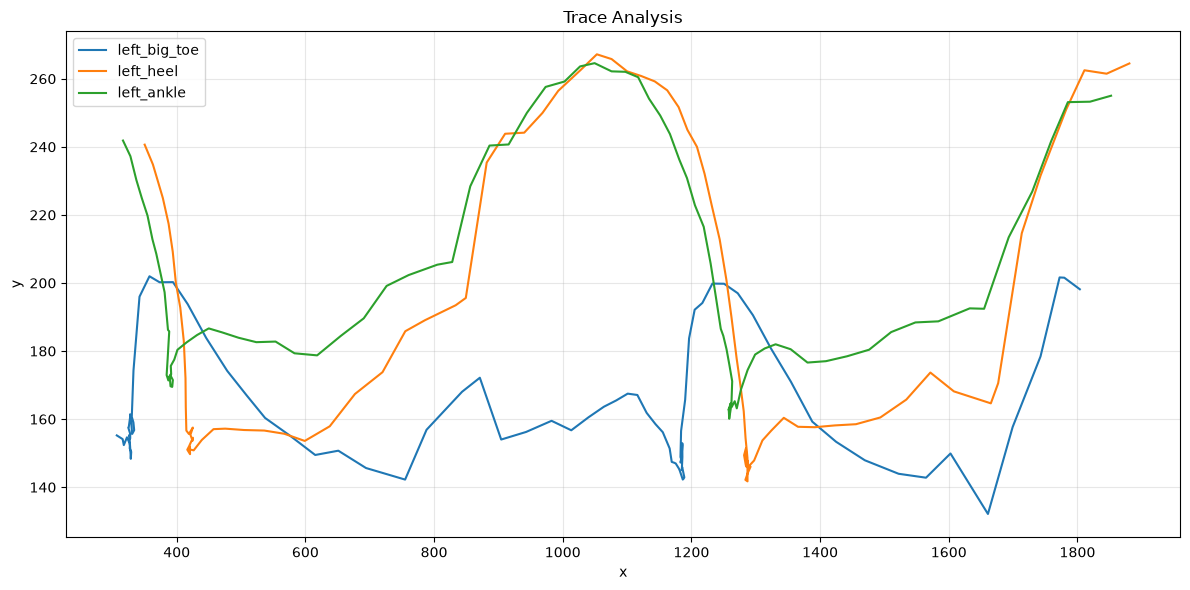

In [64]:
visualize_xy(ps.df[["left_heel_x", "left_heel_y", "left_big_toe_x", "left_big_toe_y", "left_ankle_x", "left_ankle_y"]])

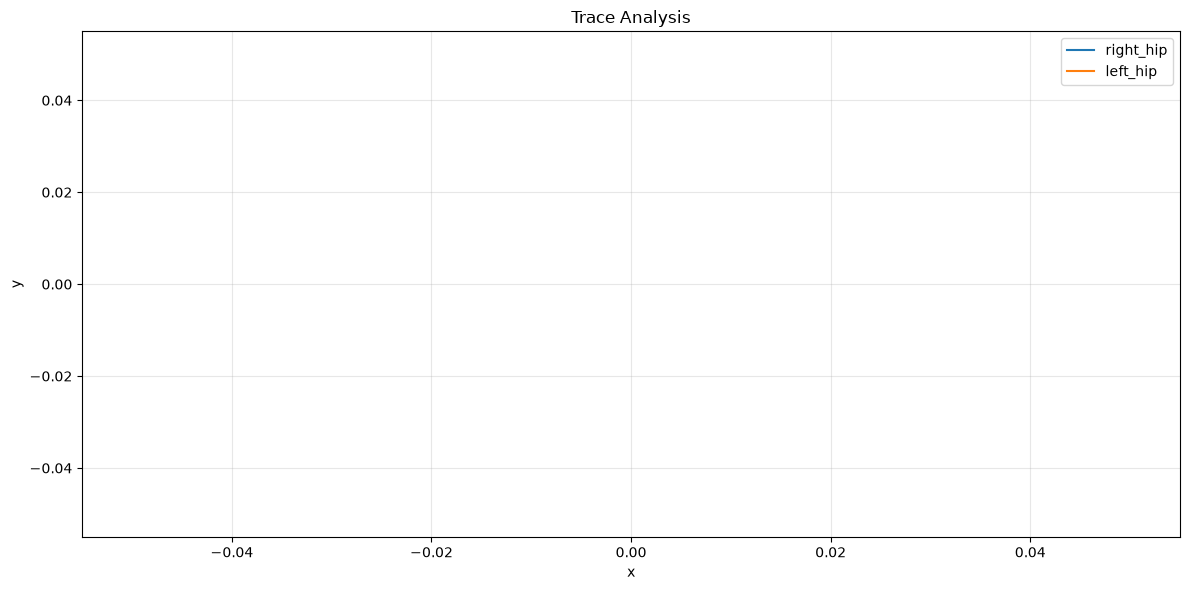

In [63]:
visualize_xy((ps.df[["left_hip_x", "left_hip_y"]] + ps.df[["right_hip_x", "right_hip_y"]]).loc[start:end])

In [54]:
hip_center = pd.DataFrame({
    "hip_center_x": (
        ps.df["left_hip_x"] + ps.df["right_hip_x"]
    ) / 2,
    "hip_center_y": (
        ps.df["left_hip_y"] + ps.df["right_hip_y"]
    ) / 2,
})

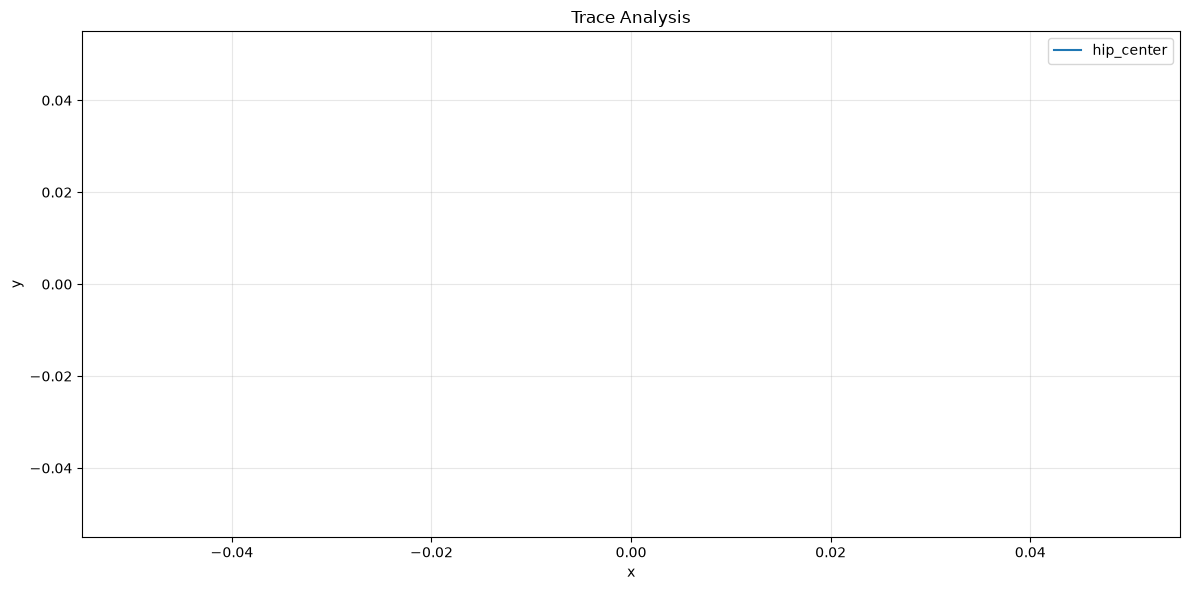

In [55]:
utils.visualize_xy(hip_center[start:end])

In [56]:
hip_center[start:end]['hip_center_y'].agg(['min', 'max'])

min   NaN
max   NaN
Name: hip_center_y, dtype: float64

In [57]:
hip_center = ps.df[
    ["left_hip_y", "right_hip_y"]
].mean(axis=1)

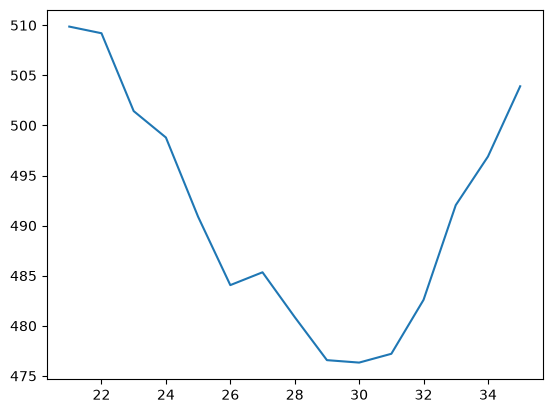

In [58]:
plt.plot(hip_center[21:36])

In [59]:
a = hip_center[21:36].agg(['min', 'max'])

In [60]:
a

min    476.328555
max    509.865755
dtype: float64

In [61]:
a.diff()['max']

np.float64(33.53720029195142)

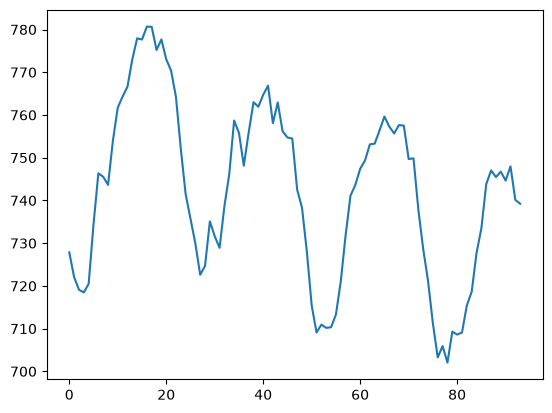

In [62]:
plt.plot(ps.df['bbox_up'] - ps.df['bbox_down'])